## Data Cleaning

In [30]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("data/communities.data", header=None, na_values='?')

df = df.dropna(thresh=len(df) * 0.5, axis=1)
df = df.fillna(df.median(numeric_only=True))

print("Датасет готовий!")
print(f"Кількість стовпців: {df.shape[1]}")

Датасет готовий!
Кількість стовпців: 104


## Залежність рівня злочинності від рівня бідності

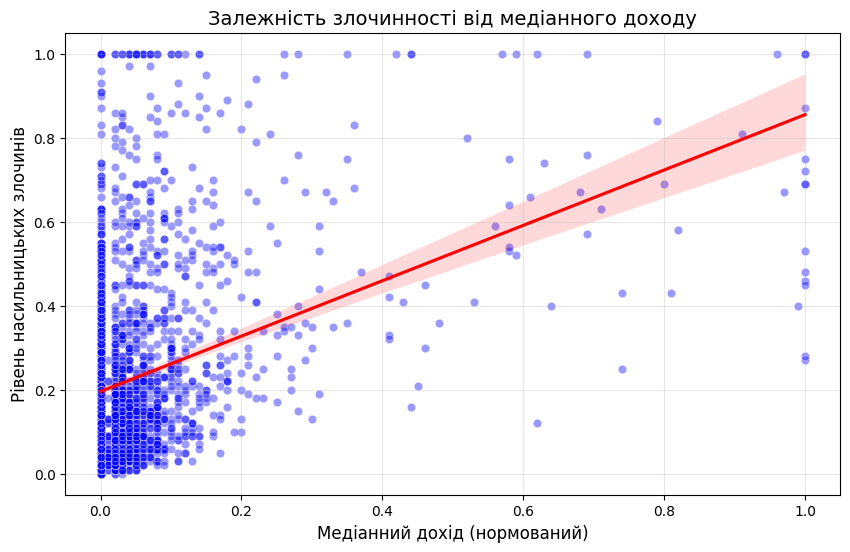

In [31]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=df[15], y=df[127], alpha=0.4, color='blue')
sns.regplot(x=df[15], y=df[127], scatter=False, color='red')

plt.title('Залежність злочинності від медіанного доходу', fontsize=14)
plt.xlabel('Медіанний дохід (нормований)', fontsize=12)
plt.ylabel('Рівень насильницьких злочинів', fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

## Розподіл рівня бідності за 5 діапазонами

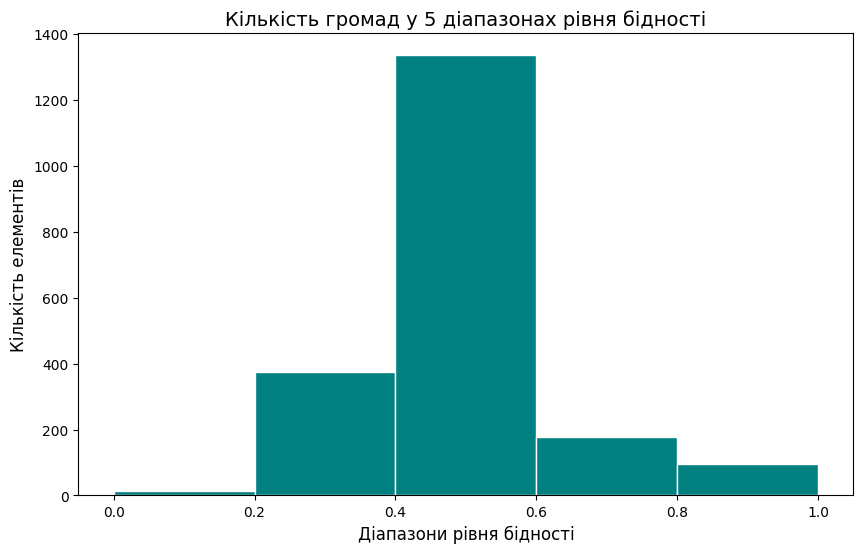

In [32]:
plt.figure(figsize=(10, 6))
counts, bins, patches = plt.hist(df[12], bins=5, color='teal', edgecolor='white')

plt.title('Кількість громад у 5 діапазонах рівня бідності', fontsize=14)
plt.xlabel('Діапазони рівня бідності', fontsize=12)
plt.ylabel('Кількість елементів', fontsize=12)
plt.xticks(bins)
plt.show()

## Порівняння розподілу злочинності за рівнями доходу (Box Plot)

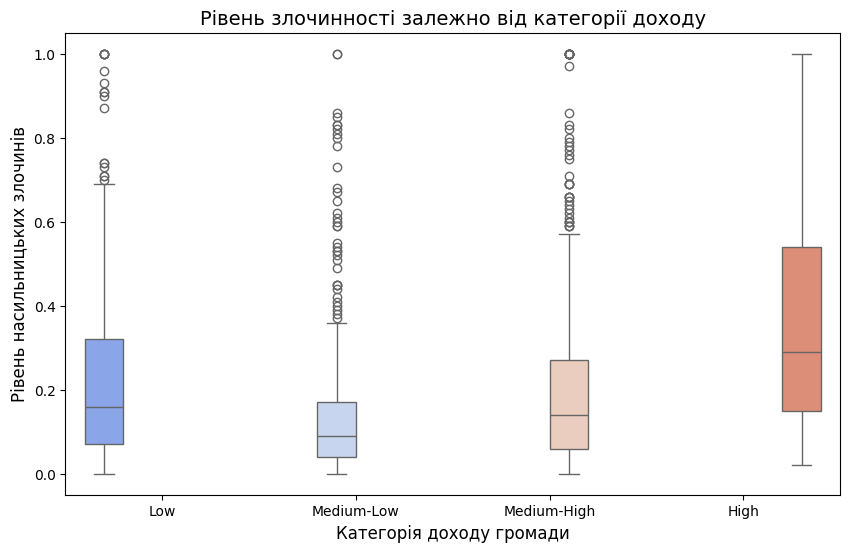

In [33]:
df = df.copy()
df['income_level'] = pd.qcut(df[15].rank(method='first'), q=4, labels=['Low', 'Medium-Low', 'Medium-High', 'High'])

plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='income_level', y=127, hue='income_level', palette='coolwarm', legend=False)

plt.title('Рівень злочинності залежно від категорії доходу', fontsize=14)
plt.xlabel('Категорія доходу громади', fontsize=12)
plt.ylabel('Рівень насильницьких злочинів', fontsize=12)
plt.show()

## Багатовимірна візуалізація: Вплив бідності та безробіття (Bubble Chart)

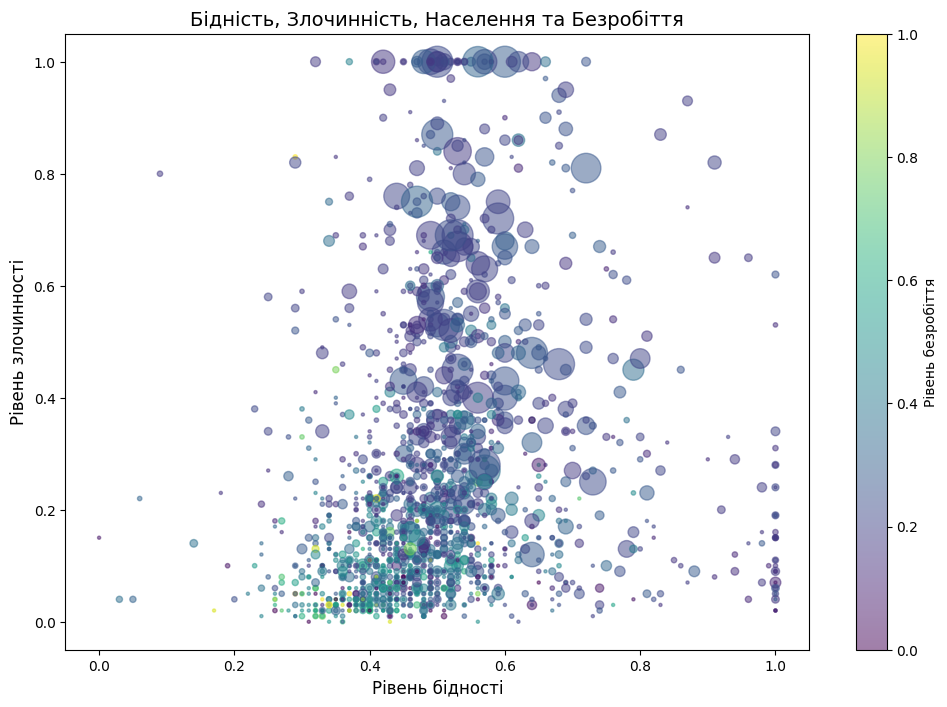

In [34]:
plt.figure(figsize=(12, 8))
# x=бідність(12), y=злочинність(127), розмір=населення(5), колір=безробіття(27)
scatter = plt.scatter(df[12], df[127], s=df[5]*500, c=df[27], cmap='viridis', alpha=0.5)

plt.colorbar(scatter, label='Рівень безробіття')
plt.title('Бідність, Злочинність, Населення та Безробіття', fontsize=14)
plt.xlabel('Рівень бідності', fontsize=12)
plt.ylabel('Рівень злочинності', fontsize=12)
plt.show()

## Матриця кореляції топ-показників (Heatmap)

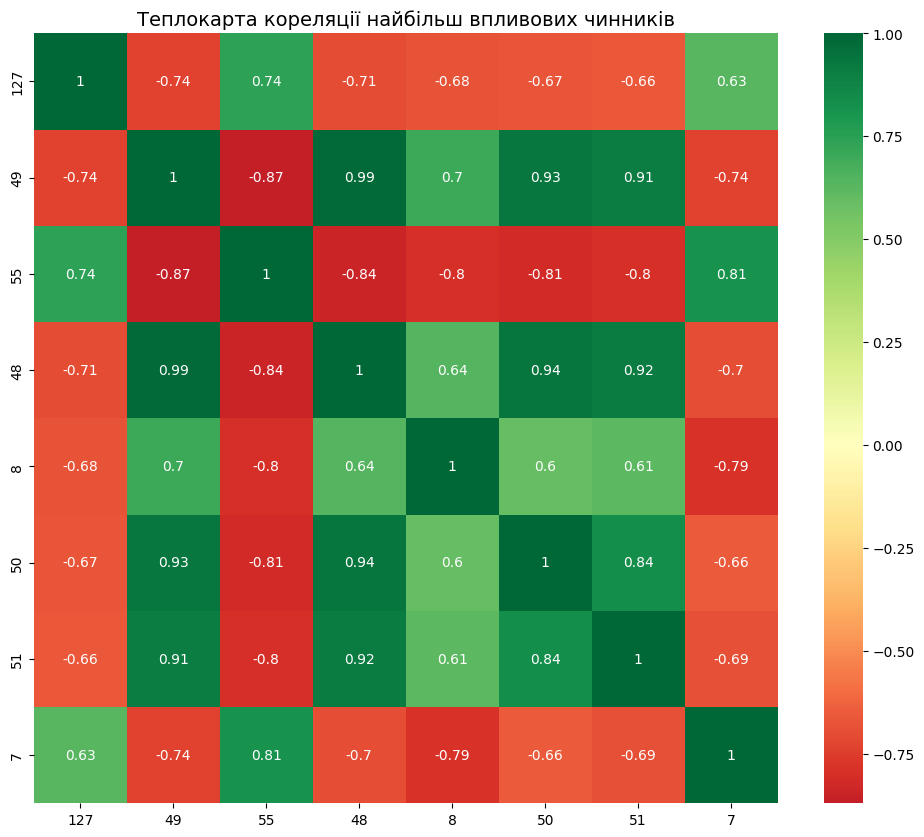

In [35]:
target_corr = df.corr(numeric_only=True)[127].abs().sort_values(ascending=False)
top_features = target_corr.head(8).index
corr_matrix = df[top_features].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='RdYlGn', center=0)

plt.title('Теплокарта кореляції найбільш впливових чинників', fontsize=14)
plt.show()

## Розподіл безробіття за категоріями доходу (Violin Plot)

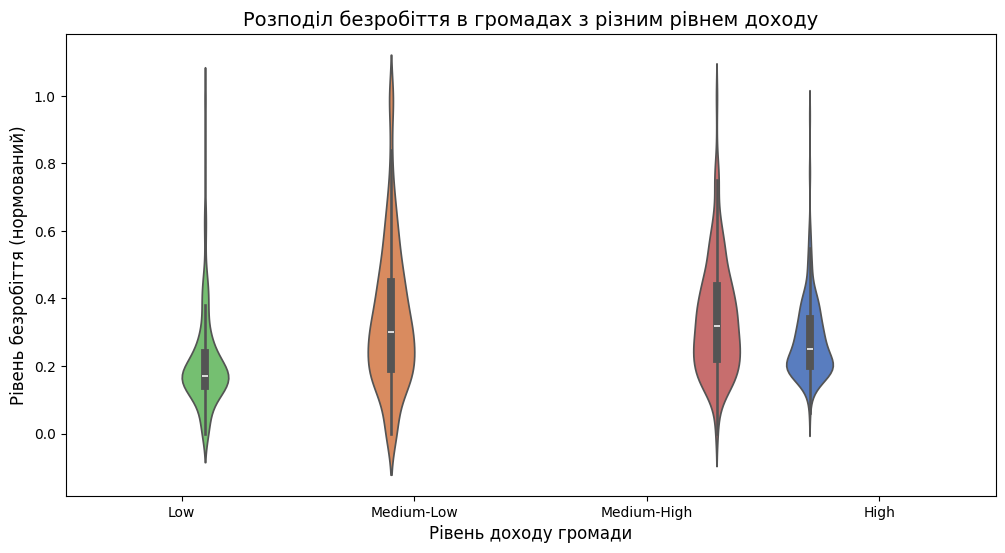

In [36]:
plt.figure(figsize=(12, 6))
sns.violinplot(data=df, x='income_level', y=27, hue='income_level', palette='muted', legend=False)

plt.title('Розподіл безробіття в громадах з різним рівнем доходу', fontsize=14)
plt.xlabel('Рівень доходу громади', fontsize=12)
plt.ylabel('Рівень безробіття (нормований)', fontsize=12)
plt.show()

## Висновки

У результаті аналізу було виявлено сильну пряму кореляцію між рівнем бідності та кількістю злочинів. Багатовимірна візуалізація показала, що громади з високим рівнем безробіття та низьким доходом мають значно вищі ризики криміналізації.